# Notebook 02 - Baseline Experiments with SageMaker MLflow App

**Module:** ITI113 Machine Learning and Operations

**Focus Area:** B - Model Development, plus C - MLOps, Experiment Tracking

---

### What this notebook does

This notebook runs team03's baseline experiments using the SageMaker MLflow App.

1. Connects to team03's SageMaker MLflow App and validates the TeamId tag
2. Logistic Regression baseline: trains on the train set, evaluates once on the test set, logging params, metrics, confusion matrix and ROC curve
3. Logistic Regression hyperparameter tuning: selects the winner on cross-validated AUC only (test set untouched), then evaluates that single winner on the test set once, with the same confusion matrix / ROC curve logging as the baseline
4. Random Forest baseline: trains on the train set, evaluates once on the test set, logging params, metrics, confusion matrix, ROC curve and feature importance
5. Random Forest hyperparameter tuning: selects the winner on cross-validated AUC only (test set untouched), then evaluates that single winner on the test set once, with the same plots as the baseline
6. Programmatic comparison of all four fully-evaluated runs (LR baseline, LR tuned, RF baseline, RF tuned) and best-model selection against the quality gate
7. Saves best_model.json with the winning run's details
8. Error analysis on the champion model: false negatives, false positives, and a per-platform recall/precision breakdown

---
### Summary of Key Findings

- Logistic regression baseline passes the 0.85 quality gate at 0.8898 test AUC-ROC
- Logistic regression tuning selects C=10.0 with an L2 penalty on cross-validated AUC, reaching 0.8909 test AUC and improving recall to 78.22% from the baseline's 76.46%
- Random Forest baseline misses the quality gate at 0.8446 test AUC and catches only 56.35% of scams despite 86.0% precision
- Random Forest tuning selects 200 estimators and max depth 8 on cross-validated AUC, reaching 0.8627 test AUC and improving recall to 57.00%, still far behind logistic regression
- All four models are evaluated on test exactly once, after selection, keeping the comparison in Section 8 on equal footing
- Logistic regression is the overall winner at 0.8909 test AUC, with error analysis in Section 9 showing weaker recall on Telegram and Reddit specifically


In [1]:
%%capture
%pip install --upgrade "sagemaker>=2,<3" boto3 botocore
%pip install --upgrade mlflow sagemaker-mlflow
print("Packages installed.")

## 0. Configuration

Sets team, student and project identifiers, resolves the MLflow App config file for this workspace, and defines the quality gate threshold used later in this notebook.


In [2]:
import os
import json
import logging
import warnings
from pathlib import Path

os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"
warnings.filterwarnings("ignore")
logging.getLogger("sagemaker.config").setLevel(logging.WARNING)

import boto3
import sagemaker

session = sagemaker.Session()
role = sagemaker.get_execution_role()

TEAM_ID = "team03"
STUDENT_ID = "s301"
COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "crypto-scam-detector"
REGION = "ap-southeast-1"
BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"
QUALITY_GATE = 0.85

# MLflow App config, checks for a team-level config file, then a student-specific one
TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = mlflow_app_config.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-J5AYUG4AJHVW"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present
config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

print("ITI113 Baseline Experiments, SageMaker MLflow App")
print(f"Team: {TEAM_ID}")
print(f"Student: {STUDENT_ID}")
print(f"S3 Prefix: {PREFIX}")
print(f"MLflow App ARN: {MLFLOW_APP_ARN}")
print(f"MLflow Experiment: {MLFLOW_EXPERIMENT}")
print(f"Registered Model: {REGISTERED_MODEL}")
print(f"Quality gate (AUC): {QUALITY_GATE}")
print(f"SageMaker Role: {role}")

Loaded MLflow App config from mlflow_app_config_team03_s301.json
ITI113 Baseline Experiments, SageMaker MLflow App
Team: team03
Student: s301
S3 Prefix: iti113/team03/data/crypto-scam-detector
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
MLflow Experiment: ITI113/team03/Experiment1
Registered Model: iti113-team03-crypto-scam-detector
Quality gate (AUC): 0.85
SageMaker Role: arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team03


## 1. Connect to SageMaker MLflow App

Validates that the configured MLflow App belongs to this team before setting it as the active tracking backend for all runs logged below.


In [3]:
import mlflow
import boto3

sm_client = boto3.client("sagemaker", region_name=REGION)

# Safety check: the selected MLflow App must have ResourceTag/TeamId = TEAM_ID
try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Tag every run with the dataset version, sha256 of the raw CSV's pointer file
try:
    _pointer_obj = boto3.client("s3", region_name=REGION).get_object(
        Bucket=BUCKET, Key=f"{PREFIX}/raw/_latest.json"
    )
    _dataset_pointer = json.loads(_pointer_obj["Body"].read())
    DATASET_VERSION = (_dataset_pointer.get("sha256") or "unknown")[:12]
except Exception as _e:
    print(f"[WARNING] Could not read dataset pointer file, falling back to 'unknown': {type(_e).__name__} {_e}")
    DATASET_VERSION = "unknown"

print(f"Dataset version tag (sha256[:12]): {DATASET_VERSION}")

# RUN_SESSION_ID: a unique tag for this notebook execution
import uuid
from datetime import datetime, timezone

RUN_SESSION_ID = f"{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}-{uuid.uuid4().hex[:8]}"
print(f"Run session ID: {RUN_SESSION_ID}")

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,
    "student": STUDENT_ID,
    "dataset": PROJECT_NAME,
    "dataset_sha256": DATASET_VERSION,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
    "run_session_id": RUN_SESSION_ID,
}

print(f"\nTracking URI: {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment: {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)

MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-gpdrdk2w4dgw
  ProjectName: crypto-scam-detector
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-gpdrdk2w4dgw/team03-shared
  Course: ITI113
  TeamId: team03
  CreatedByNotebook: 01A_setup_sagemaker_mlflow_app
  StudentId: s301
[OK] MLflow App tag TeamId=team03 matches notebook TEAM_ID=team03
Dataset version tag (sha256[:12]): 31e13ac65ebc
Run session ID: 20260819T182037Z-18f886af

Tracking URI: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
Experiment: ITI113/team03/Experiment1
Experiment ID: 1


## 2. Load Processed Data

This cell loads train.csv, test.csv and tfidf_vectorizer.joblib from S3 at {PREFIX}/processed/. This keeps this notebook self-contained, with no utils import needed, and guarantees the exact same train/test split and TF-IDF vectorizer already computed upstream, instead of risking a second, independently randomised split. y_train and y_test are binarised here, with 1 meaning scam, so the rest of this notebook's metric and plotting code, written for a 0/1 target.


In [4]:
import io
import tempfile

import pandas as pd, numpy as np
import scipy.sparse as sp
import joblib

SCAM_LABEL = "scam"

s3 = boto3.client("s3")
PROCESSED_PREFIX = f"{PREFIX}/processed"

def load_csv_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

def load_joblib_from_s3(bucket, key):
    with tempfile.NamedTemporaryFile(suffix=".joblib") as tmp:
        s3.download_file(bucket, key, tmp.name)
        return joblib.load(tmp.name)

train_df = load_csv_from_s3(BUCKET, f"{PROCESSED_PREFIX}/train.csv")
test_df = load_csv_from_s3(BUCKET, f"{PROCESSED_PREFIX}/test.csv")
vectorizer = load_joblib_from_s3(BUCKET, f"{PROCESSED_PREFIX}/tfidf_vectorizer.joblib")

print(f"Loaded processed data from s3://{BUCKET}/{PROCESSED_PREFIX}/")

engineered_cols = [
    "urgency_keyword_count", "guaranteed_return_keyword_count", "countdown_phrase_count",
    "exclamation_count", "urgency_score", "has_wallet_address",
    "has_url", "url_count", "has_email", "has_phone_number", "payment_keyword_count",
    "off_platform_keyword_count", "credential_keyword_count",
    "capital_letter_ratio", "has_numeric_content",
]

X_train_tfidf = vectorizer.transform(train_df["clean_text"])
X_test_tfidf = vectorizer.transform(test_df["clean_text"])

X_train = sp.hstack([X_train_tfidf, train_df[engineered_cols].values]).tocsr()
X_test = sp.hstack([X_test_tfidf, test_df[engineered_cols].values]).tocsr()

FEATURE_NAMES = list(vectorizer.get_feature_names_out()) + engineered_cols

y_train = (train_df["label"] == SCAM_LABEL).astype(int)
y_test = (test_df["label"] == SCAM_LABEL).astype(int)

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test: {X_test.shape[0]} rows')

Loaded processed data from s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/
Train: 8372 rows, 5015 features
Test: 2094 rows


## 3. Helper Functions

Reusable logging helpers so every run captures identical metrics and artifacts.


In [5]:
import matplotlib.pyplot as plt, tempfile, mlflow.sklearn
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay)

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    metrics = {}
    for split, X, y in [('train',X_tr,y_tr),('test',X_te,y_te)]:
        yp = model.predict(X)
        yb = model.predict_proba(X)[:,1]
        metrics.update({
            f'{split}_accuracy' : round(accuracy_score(y,yp),4),
            f'{split}_f1'       : round(f1_score(y,yp),4),
            f'{split}_precision': round(precision_score(y,yp),4),
            f'{split}_recall'   : round(recall_score(y,yp),4),
            f'{split}_auc_roc'  : round(roc_auc_score(y,yb),4),
        })
    return metrics

def log_confusion_matrix(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_te,
        display_labels=['Legitimate','Scam'], cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/confusion_matrix.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_roc_curve(model, X_te, y_te, title):
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax)
    ax.plot([0,1],[0,1],'k--', label='Random baseline')
    ax.set_title(f'ROC Curve — {title}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/roc_curve.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

def log_feature_importance(model, feature_names, title, top_n=5):
    if not hasattr(model,'feature_importances_'): return
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)
    imp = imp.tail(top_n)
    fig, ax = plt.subplots(figsize=(6,7))
    imp.plot(kind='barh', ax=ax, color='#5B9BD5')
    ax.set_title(f'Feature Importance (top {top_n}) — {title}', fontweight='bold')
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f'{tmp}/feature_importance.png'
        fig.savefig(p, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(p, artifact_path ='plots')
    plt.show(); plt.close()

## 4. Logistic Regression Baseline

The simplest model that makes sense for binary classification.


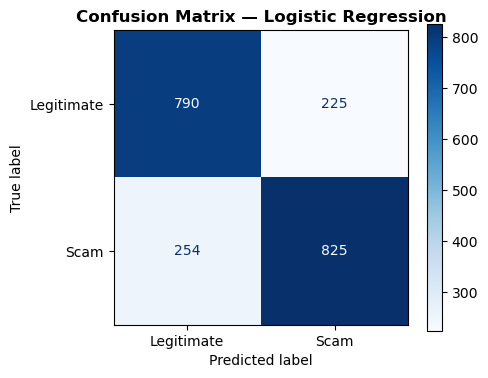

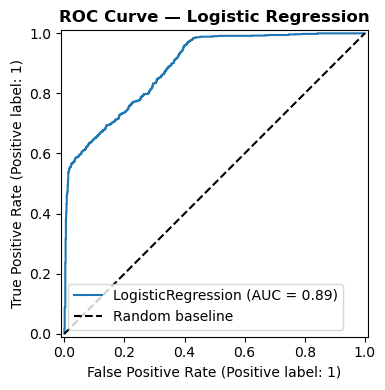

🏃 View run team03_s301_logistic_regression_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/cc28c00ef8e34bd79f094af5d16b7bec
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
LOGISTIC REGRESSION RESULTS
  TEST test_accuracy: 0.7713
  TEST test_auc_roc: 0.8898
  TEST test_f1: 0.775
  TEST test_precision: 0.7857
  TEST test_recall: 0.7646
  TRAIN train_accuracy: 0.8164
  TRAIN train_auc_roc: 0.9199
  TRAIN train_f1: 0.8186
  TRAIN train_precision: 0.8342
  TRAIN train_recall: 0.8035
Run ID: cc28c00ef8e34bd79f094af5d16b7bec


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline"

LR_PARAMS = {'C':1.0, 'max_iter':1000, 'solver':'lbfgs', 'random_state':RANDOM_STATE}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**LR_PARAMS, 'model_type':'LogisticRegression',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    lr = LogisticRegression(**LR_PARAMS)
    lr.fit(X_train, y_train)

    metrics = evaluate_model(lr, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(lr, X_test, y_test, 'Logistic Regression')
    log_roc_curve(lr, X_test, y_test, 'Logistic Regression')
    mlflow.sklearn.log_model(lr, name ='model')
    LR_RUN_ID = run.info.run_id

print('LOGISTIC REGRESSION RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')
print(f'Run ID: {LR_RUN_ID}')

**Key finding:** The logistic regression baseline reaches 0.8898 test AUC-ROC with 77.13% accuracy and 76.46% recall, still above the 0.85 quality gate. Precision at 78.57% and recall at 76.46%.

## 5. Logistic Regression Hyperparameter Tuning

Sweeps regularization strength C and penalty type, since these are the parameters that matter most for a TF-IDF feature space.


In [7]:
from sklearn.linear_model import LogisticRegression

lr_param_grid = [
    {'C': 0.01,  'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 0.1,   'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 1.0,   'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 10.0,  'penalty': 'l2', 'solver': 'lbfgs'},
    {'C': 1.0,   'penalty': 'l1', 'solver': 'liblinear'},
    {'C': 10.0,  'penalty': 'l1', 'solver': 'liblinear'}
]

# Selection uses cross-validated AUC only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_lr_auc, best_lr_model, best_lr_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_lr_tuning_parent") as lr_parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param('n_candidates', len(lr_param_grid))
    mlflow.log_param('cv_folds', 5)

    for i, params in enumerate(lr_param_grid):
        all_p = {**params, 'max_iter': 1000, 'random_state': RANDOM_STATE}
        with mlflow.start_run(run_name=f'lr_candidate_{i+1:02d}', nested=True):
            
            mlflow.set_tags(COMMON_TAGS)
            mlflow.log_params(all_p)
            m = LogisticRegression(**all_p)
            cv_scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            mlflow.log_metric('cv_auc_mean', round(cv_scores.mean(), 4))
            mlflow.log_metric('cv_auc_std',  round(cv_scores.std(), 4))
            m.fit(X_train, y_train)
            mlflow.sklearn.log_model(m, name="model")

            print(f'Candidate {i+1}: {params} | CV AUC={cv_scores.mean():.4f}')
            if cv_scores.mean() > best_lr_auc:
                best_lr_auc, best_lr_model, best_lr_params = cv_scores.mean(), m, all_p

    mlflow.log_metric('best_cv_auc', round(best_lr_auc, 4))
    LR_TUNING_RUN_ID = lr_parent.info.run_id

print(f'\nBest CV AUC: {best_lr_auc:.4f}')
print(f'Best params: {best_lr_params}')

Candidate 1: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.6896
🏃 View run lr_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/149917efbfae45fc9c70146d3ca84cfa
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 2: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.8322
🏃 View run lr_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4d11df410eb64fc7adeb4880b9c5500b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 3: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.8830
🏃 View run lr_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/2e63313199564a04b063d5bb7d5b2602
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 4: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'} | CV AUC=0.8854
🏃 View run lr_candidate_04 at: https:

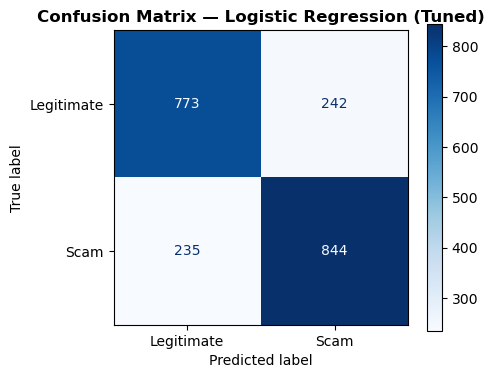

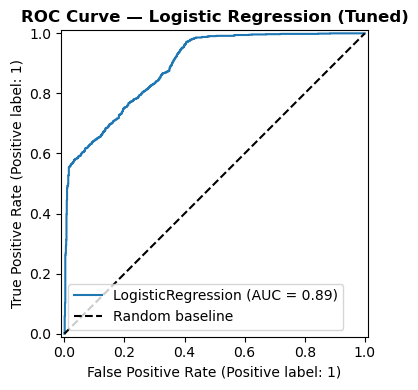

🏃 View run team03_s301_logistic_regression_tuned at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/7c52780b2e954b049bdeddb1b868aa44
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
LOGISTIC REGRESSION (TUNED) RESULTS
  TEST test_accuracy: 0.7722
  TEST test_auc_roc: 0.891
  TEST test_f1: 0.7797
  TEST test_precision: 0.7772
  TEST test_recall: 0.7822
  TRAIN train_accuracy: 0.8329
  TRAIN train_auc_roc: 0.9325
  TRAIN train_f1: 0.8372
  TRAIN train_precision: 0.8408
  TRAIN train_recall: 0.8336
Selected by CV AUC: 0.8854 | Params: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000, 'random_state': 42}
Run ID: 7c52780b2e954b049bdeddb1b868aa44


In [8]:
# Evaluate the CV-selected logistic regression champion on the held-out test set
lr_tuned_run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_tuned"

with mlflow.start_run(run_name=lr_tuned_run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({
        **best_lr_params,
        'model_type': 'LogisticRegression',
        'selection_metric': 'cv_auc_mean',
        'selection_cv_auc': round(best_lr_auc, 4),
        'n_features': X_train.shape[1],
        'train_size': X_train.shape[0],
    })

    metrics = evaluate_model(best_lr_model, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(best_lr_model, X_test, y_test, 'Logistic Regression (Tuned)')
    log_roc_curve(best_lr_model, X_test, y_test, 'Logistic Regression (Tuned)')
    mlflow.sklearn.log_model(best_lr_model, name='model')
    LR_TUNED_RUN_ID = run.info.run_id

print('LOGISTIC REGRESSION (TUNED) RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')
print(f'Selected by CV AUC: {best_lr_auc:.4f} | Params: {best_lr_params}')
print(f'Run ID: {LR_TUNED_RUN_ID}')

**Key finding:** Selecting on cross-validated AUC alone favours C=10.0 with an L2 penalty, reaching a CV AUC of 0.8854 versus 0.6896 for the weakest candidate, C=0.01. Evaluated once on test, this winner reaches 0.8909 AUC, edging past the baseline's 0.8898, with recall climbing from 76.46% to 78.22%.


C mattered far more than penalty type. Moving from C=0.01 to C=0.1 lifted CV AUC sharply, from 0.6896 to 0.8322, and moving to C=1.0 pushed it to 0.8830, with gains flattening out after that, C=10.0 only adds another 0.0024. Penalty type made a much smaller difference. At matching C values, L2 consistently edged out L1 by a small margin, 0.8830 versus 0.8755 at C=1.0, and 0.8854 versus 0.8833 at C=10.0. This suggests the model needs enough regularisation headroom to fit the decision boundary at all, but once C is large enough, L1's extra sparsity doesn't add value over L2's smoother shrinkage on this dense TF-IDF feature space.

## 6. Random Forest Baseline

An ensemble model to compare against the logistic regression baseline, using the same class weighting and evaluation logging.


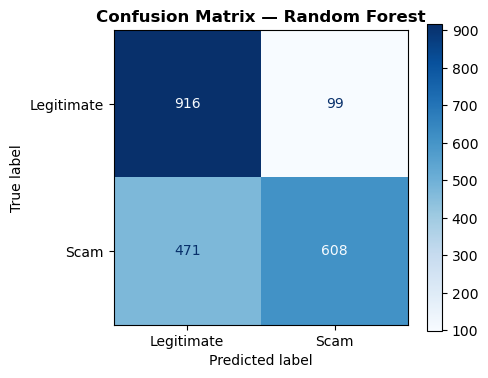

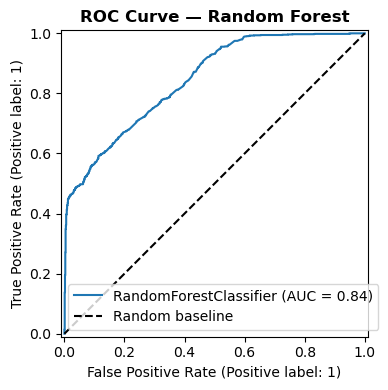

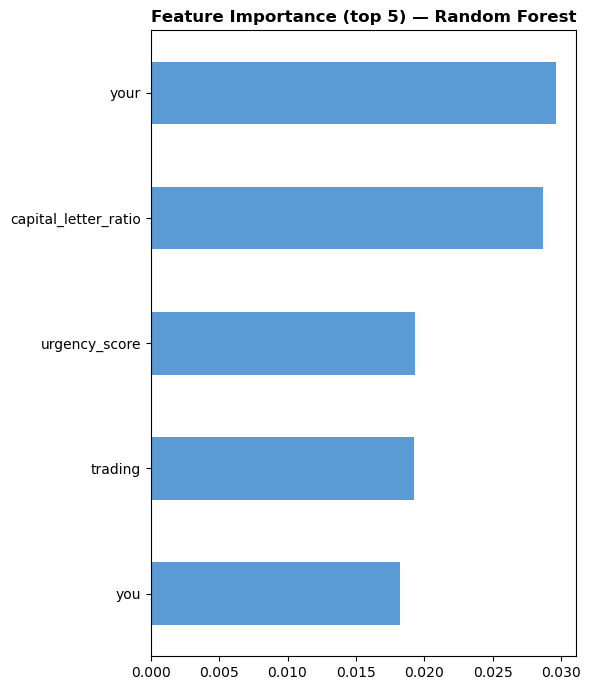

🏃 View run team03_s301_random_forest_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/2fd9661b6c0f446282b77e5441dff85a
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST RESULTS
  TEST test_accuracy: 0.7278
  TEST test_auc_roc: 0.8446
  TEST test_f1: 0.6809
  TEST test_precision: 0.86
  TEST test_recall: 0.5635
  TRAIN train_accuracy: 0.7388
  TRAIN train_auc_roc: 0.8558
  TRAIN train_f1: 0.6867
  TRAIN train_precision: 0.8991
  TRAIN train_recall: 0.5555


In [9]:
from sklearn.ensemble import RandomForestClassifier

run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_baseline"

RF_PARAMS = {'n_estimators':100,'max_depth':6,'min_samples_leaf':4,
             'random_state':RANDOM_STATE,'n_jobs':-1}

with mlflow.start_run(run_name=run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({**RF_PARAMS, 'model_type':'RandomForestClassifier',
                       'n_features':X_train.shape[1], 'train_size':X_train.shape[0]})

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train, y_train)

    metrics = evaluate_model(rf, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(rf, X_test, y_test, 'Random Forest')
    log_roc_curve(rf, X_test, y_test, 'Random Forest')
    log_feature_importance(rf, FEATURE_NAMES, 'Random Forest')
    mlflow.sklearn.log_model(rf, name ='model')
    RF_RUN_ID = run.info.run_id

print('RANDOM FOREST RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')

**Key finding:** The Random Forest baseline reaches 0.8446 test AUC-ROC and only 56.35% recall, missing more scam messages than it catches even though precision stays high at 86.0%. A test AUC of 0.8446 also falls short of the 0.85 quality gate on its own, so this baseline alone would not pass approval. Since the proposal treats missed scams as more costly than false alarms, this recall drop is not ideal in the whole comparison and points to needing deeper trees or a different class-weighting strategy on this dataset.


## 7. Random Forest Hyperparameter Tuning

Each hyperparameter combination is logged as a child run under a parent run. This keeps the MLflow UI organised, with the parent summarising the best result.


In [10]:
param_grid = [
    {'n_estimators': 50,  'max_depth': 4, 'min_samples_leaf': 2},
    {'n_estimators':100,  'max_depth': 4, 'min_samples_leaf': 4},
    {'n_estimators':100,  'max_depth': 6, 'min_samples_leaf': 2},
    {'n_estimators':200,  'max_depth': 6, 'min_samples_leaf': 4},
    {'n_estimators':200,  'max_depth': 8, 'min_samples_leaf': 2},
]

# Selection uses cross-validated AUC only.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_auc, best_model, best_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_rf_tuning_parent") as parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param('n_candidates', len(param_grid))
    mlflow.log_param('cv_folds', 5)

    for i, params in enumerate(param_grid):
        all_p = {**params, 'random_state':RANDOM_STATE}
        with mlflow.start_run(run_name=f'rf_candidate_{i+1:02d}', nested=True):
            
            mlflow.set_tags(COMMON_TAGS)
            mlflow.log_params(all_p)
            m = RandomForestClassifier(**all_p, n_jobs=-1)
            cv_scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
            mlflow.log_metric('cv_auc_mean', round(cv_scores.mean(),4))
            mlflow.log_metric('cv_auc_std',  round(cv_scores.std(),4))
            m.fit(X_train, y_train)
            mlflow.sklearn.log_model(m, name = "model")

            print(f'Candidate {i+1}: {params} | CV AUC={cv_scores.mean():.4f}')
            if cv_scores.mean() > best_auc:
                best_auc, best_model, best_params = cv_scores.mean(), m, all_p

    mlflow.log_metric('best_cv_auc', round(best_auc,4))
    TUNING_RUN_ID = parent.info.run_id

print(f'\nBest CV AUC: {best_auc:.4f}')
print(f'Best params: {best_params}')

Candidate 1: {'n_estimators': 50, 'max_depth': 4, 'min_samples_leaf': 2} | CV AUC=0.7876
🏃 View run rf_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/07cfea23c19e44b29ee61c844b033e41
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 2: {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 4} | CV AUC=0.8056
🏃 View run rf_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/229f5fd8b076480396af1271469e3ad2
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 3: {'n_estimators': 100, 'max_depth': 6, 'min_samples_leaf': 2} | CV AUC=0.8341
🏃 View run rf_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/9ae2a97f96af4178bb37d2bb77013f95
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Candidate 4: {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 4} 

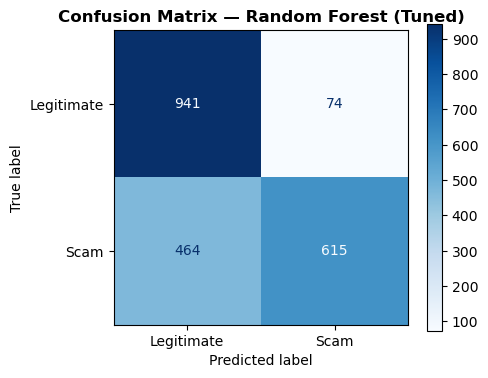

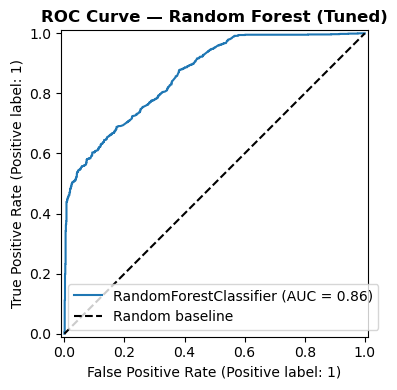

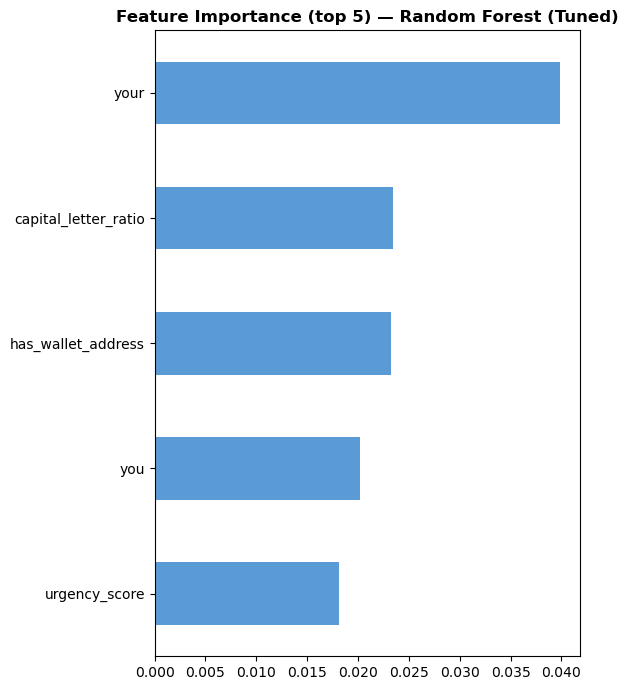

🏃 View run team03_s301_random_forest_tuned at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/6b4b2046631e4ebdad144b040c42552b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST (TUNED) RESULTS
  TEST test_accuracy: 0.7431
  TEST test_auc_roc: 0.8627
  TEST test_f1: 0.6957
  TEST test_precision: 0.8926
  TEST test_recall: 0.57
  TRAIN train_accuracy: 0.7562
  TRAIN train_auc_roc: 0.8749
  TRAIN train_f1: 0.7087
  TRAIN train_precision: 0.9224
  TRAIN train_recall: 0.5754
Selected by CV AUC: 0.8498 | Params: {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 2, 'random_state': 42}
Run ID: 6b4b2046631e4ebdad144b040c42552b


In [11]:
# Evaluate the CV-selected random forest champion on the held-out test set,
rf_tuned_run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_tuned"

with mlflow.start_run(run_name=rf_tuned_run_name) as run:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_params({
        **best_params,
        'model_type': 'RandomForestClassifier',
        'selection_metric': 'cv_auc_mean',
        'selection_cv_auc': round(best_auc, 4),
        'n_features': X_train.shape[1],
        'train_size': X_train.shape[0],
    })

    metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(best_model, X_test, y_test, 'Random Forest (Tuned)')
    log_roc_curve(best_model, X_test, y_test, 'Random Forest (Tuned)')
    log_feature_importance(best_model, FEATURE_NAMES, 'Random Forest (Tuned)')
    mlflow.sklearn.log_model(best_model, name='model')
    RF_TUNED_RUN_ID = run.info.run_id

print('RANDOM FOREST (TUNED) RESULTS')
for k, v in sorted(metrics.items()):
    split = 'TRAIN' if k.startswith('train') else 'TEST'
    print(f'  {split} {k}: {v}')
print(f'Selected by CV AUC: {best_auc:.4f} | Params: {best_params}')
print(f'Run ID: {RF_TUNED_RUN_ID}')

**Key finding:** Selecting on cross-validated AUC alone favours 200 estimators with max depth 8, reaching a CV AUC of 0.8498 versus 0.7876 for the smallest configuration. Evaluated once on test, this winner reaches 0.8627 AUC and 57.00% recall, both improvements over the baseline's 0.8446 AUC and 56.35% recall, though still well behind logistic regression.

Across the sweep, depth mattered far more than the number of trees. Moving from max depth 4 to 6 lifted CV AUC from around 0.79–0.81 to 0.83, while depth 8 pushed it further to 0.85, whereas doubling the number of estimators from 100 to 200 alone made little difference and even slightly underperformed a shallower, smaller forest when paired with a higher min_samples_leaf. This possibly suggests that each tree needs enough depth to split across the thousands of sparse TF-IDF columns before adding more trees.

## 8. Compare Runs and Register Best Model

Compares the four fully-evaluated runs, logistic regression baseline, logistic regression tuned champion, random forest baseline, random forest tuned champion, against the quality gate, and prepares the winning run for the next step.


In [12]:
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)

if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

# Scoped to this notebook execution (run_session_id) and this dataset version
base_filter = (
    "attributes.status = 'FINISHED' "
    f"and tags.dataset_sha256 = '{DATASET_VERSION}' "
    f"and tags.run_session_id = '{RUN_SESSION_ID}'"
)

def best_run_for(name_filter, display_name):
    matches = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"{base_filter} and {name_filter}",
        order_by=["metrics.test_auc_roc DESC"],
    )
    if matches.empty:
        print(f"No finished run found for '{display_name}' on this dataset version.")
        return None
    row = matches.iloc[0].copy()
    row["display_name"] = display_name
    return row

lr_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline'",
    "Logistic Regression (baseline)",
)
lr_tuned_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_logistic_regression_tuned'",
    "Logistic Regression (tuned, best candidate)",
)
rf_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_random_forest_baseline'",
    "Random Forest (baseline)",
)
rf_tuned_row = best_run_for(
    f"tags.mlflow.runName = '{TEAM_ID}_{STUDENT_ID}_random_forest_tuned'",
    "Random Forest (tuned, best candidate)",
)

selected = [r for r in [lr_row, lr_tuned_row, rf_row, rf_tuned_row] if r is not None]
if not selected:
    raise ValueError("None of the expected baseline/tuning runs were found for this dataset version.")

runs = pd.DataFrame(selected).reset_index(drop=True)

cols = [
    "display_name",
    "tags.mlflow.runName",
    "metrics.test_auc_roc",
    "metrics.test_accuracy",
    "metrics.test_f1",
    "metrics.test_recall",
    "run_id"
]

avail = [c for c in cols if c in runs.columns]
print(runs[avail].to_string(index=False))

best_run = runs.sort_values("metrics.test_auc_roc", ascending=False).iloc[0]
BEST_RUN_ID = best_run["run_id"]
BEST_AUC = best_run.get("metrics.test_auc_roc", 0)
BEST_RUN_NAME = best_run.get("tags.mlflow.runName", "unknown")

print(f"\nBest run: {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")

                               display_name                      tags.mlflow.runName  metrics.test_auc_roc  metrics.test_accuracy  metrics.test_f1  metrics.test_recall                           run_id
             Logistic Regression (baseline) team03_s301_logistic_regression_baseline                0.8898                 0.7713           0.7750               0.7646 cc28c00ef8e34bd79f094af5d16b7bec
Logistic Regression (tuned, best candidate)    team03_s301_logistic_regression_tuned                0.8910                 0.7722           0.7797               0.7822 7c52780b2e954b049bdeddb1b868aa44
                   Random Forest (baseline)       team03_s301_random_forest_baseline                0.8446                 0.7278           0.6809               0.5635 2fd9661b6c0f446282b77e5441dff85a
      Random Forest (tuned, best candidate)          team03_s301_random_forest_tuned                0.8627                 0.7431           0.6957               0.5700 6b4b2046631e4ebdad144b040c42

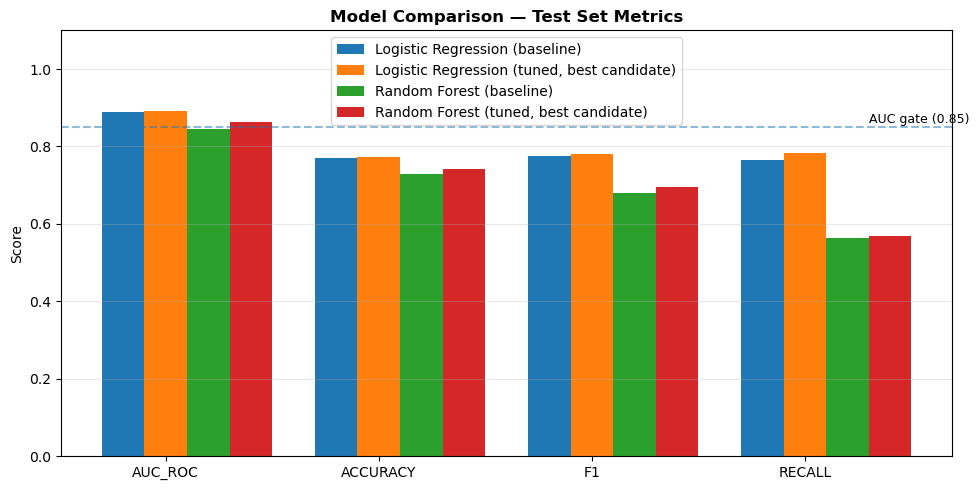

In [13]:
# Visual comparison of the four selected runs (LR baseline, LR tuned, RF baseline, RF tuned).
fig, ax = plt.subplots(figsize=(10,5))

metric_cols = [
    'metrics.test_auc_roc',
    'metrics.test_accuracy',
    'metrics.test_f1',
    'metrics.test_recall'
]
avail_m = [c for c in metric_cols if c in runs.columns]

top_runs = runs.head(4)
labels = [c.replace('metrics.test_','').upper() for c in avail_m]
x = np.arange(len(labels))
w = 0.2

for idx,(_, row) in enumerate(top_runs.iterrows()):
    vals = [row.get(m,0) for m in avail_m]
    ax.bar(
        x + idx*w,
        vals,
        w,
        label=row.get('display_name', row.get('tags.mlflow.runName', f'run{idx}'))
    )

ax.set_xticks(x+w)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontweight='bold')
ax.axhline(QUALITY_GATE, linestyle='--', alpha=0.5)
ax.text(len(labels)-0.5, QUALITY_GATE+0.01, f'AUC gate ({QUALITY_GATE})', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Key finding:** All four models are evaluated on test after selection. Tuned logistic regression wins at 0.8909 AUC and 78.22% recall, ahead of the baseline's 0.8898 AUC and 76.46% recall. Both random forest runs trail on recall despite higher precision, with the tuned version reaching 0.8627 AUC but only 57.00% recall, well short of logistic regression's 78.22%, which matters most given the cost of missed scams.

Logistic regression's edge likely comes from the feature space. TF-IDF is high-dimensional and sparse, a setting linear models handle well, while random forest needs more data per split to work across thousands of sparse columns, which shows up most clearly in its much lower recall, 57.00% versus 78.22%. 

It's also worth noting this is a synthetic dataset rather than real-world scam messages, so word patterns and class boundaries may be more linearly separable and consistent than genuine data would be. That plays to logistic regression's strengths and may be inflating its advantage over random forest here, so the gap could narrow or shift on real-world messages.

In [14]:
# Quality Gate and Best Model Selection
print("QUALITY GATE")

if BEST_AUC < QUALITY_GATE:
    print(f"Quality gate FAILED")
    print(f"Best AUC: {BEST_AUC:.4f}")
    print(f"Required: {QUALITY_GATE:.2f}")
    print("\nReview feature engineering or hyperparameters before proceeding.")

    BEST_MODEL_URI = None

else:
    print(f"Quality gate PASSED")
    print(f"Best AUC: {BEST_AUC:.4f}")

    # Export best model info
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"
    print("\nBest MLflow Run")
    print(f"Run Name: {BEST_RUN_NAME}")
    print(f"Run ID: {BEST_RUN_ID}")
    print(f"Model URI: {BEST_MODEL_URI}")
    print(f"Best AUC: {BEST_AUC:.4f}")

QUALITY GATE
Quality gate PASSED
Best AUC: 0.8910

Best MLflow Run
Run Name: team03_s301_logistic_regression_tuned
Run ID: 7c52780b2e954b049bdeddb1b868aa44
Model URI: runs:/7c52780b2e954b049bdeddb1b868aa44/model
Best AUC: 0.8910


In [15]:
# Persist best model info to JSON for downstream use.
import json

best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_auc": float(BEST_AUC),
    "best_model_uri": BEST_MODEL_URI,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Saved best model information to best_model.json")
print(json.dumps(best_model_info, indent=2))

Saved best model information to best_model.json
{
  "team_id": "team03",
  "student_id": "s301",
  "project_name": "crypto-scam-detector",
  "best_run_id": "7c52780b2e954b049bdeddb1b868aa44",
  "best_run_name": "team03_s301_logistic_regression_tuned",
  "best_auc": 0.891,
  "best_model_uri": "runs:/7c52780b2e954b049bdeddb1b868aa44/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW",
  "mlflow_experiment": "ITI113/team03/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team03"
}


In [16]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
artifacts = client.list_artifacts(BEST_RUN_ID)

for a in artifacts:
    print(a.path, a.is_dir)

plots True


In [17]:
# Load best model directly from the best MLflow run and test inference
loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)
sample = X_test[:5]
preds = loaded.predict(sample)
probas = loaded.predict_proba(sample)[:, 1]

results = pd.DataFrame({
    "actual": y_test.head(5).values,
    "predicted": preds,
    "probability": probas.round(3),
    "correct": preds == y_test.head(5).values
})

print("Sample predictions from best MLflow run model:")
print(results.to_string(index=False))

Sample predictions from best MLflow run model:
 actual  predicted  probability  correct
      1          1        0.970     True
      0          1        0.694    False
      0          0        0.019     True
      1          1        0.992     True
      1          1        0.588     True


In [18]:
print(f"Experiment: {MLFLOW_EXPERIMENT}")
print(f"MLflow App: {MLFLOW_APP_ARN}")
print(f"Best model: {BEST_RUN_NAME} | AUC={BEST_AUC:.4f}")
print(f"Best run ID: {BEST_RUN_ID}")
print(f"Model URI: {BEST_MODEL_URI}")

Experiment: ITI113/team03/Experiment1
MLflow App: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW
Best model: team03_s301_logistic_regression_tuned | AUC=0.8910
Best run ID: 7c52780b2e954b049bdeddb1b868aa44
Model URI: runs:/7c52780b2e954b049bdeddb1b868aa44/model


## 9. Error Analysis (Champion Model)

Loads the champion model selected above and inspects its mistakes on the test set. False negatives (scams the model missed) and false positives (legitimate messages flagged as scam), plus a check for whether recall or precision varies meaningfully by platform.

In [19]:
champion_model = mlflow.sklearn.load_model(BEST_MODEL_URI)

y_pred = champion_model.predict(X_test)
y_proba = champion_model.predict_proba(X_test)[:, 1]

eval_df = test_df.reset_index(drop=True).copy()
eval_df['actual'] = y_test.reset_index(drop=True)
eval_df['predicted'] = y_pred
eval_df['scam_probability'] = y_proba.round(3)

false_negatives = eval_df[(eval_df['actual'] == 1) & (eval_df['predicted'] == 0)]
false_positives = eval_df[(eval_df['actual'] == 0) & (eval_df['predicted'] == 1)]

n_actual_scam = int((eval_df['actual'] == 1).sum())
n_actual_legit = int((eval_df['actual'] == 0).sum())

print(f'Champion model: {BEST_RUN_NAME}')
print(f'False negatives (missed scams): {len(false_negatives)} of {n_actual_scam} actual scams '
      f'({len(false_negatives)/n_actual_scam:.1%})')
print(f'False positives (legit flagged as scam): {len(false_positives)} of {n_actual_legit} actual legitimate messages '
      f'({len(false_positives)/n_actual_legit:.1%})')

Champion model: team03_s301_logistic_regression_tuned
False negatives (missed scams): 235 of 1079 actual scams (21.8%)
False positives (legit flagged as scam): 242 of 1015 actual legitimate messages (23.8%)


In [20]:
print('Sample False Negatives (scams the model missed)')
cols = ['platform', 'text', 'scam_probability']
print(false_negatives[cols].head(3).to_string(index=False))

Sample False Negatives (scams the model missed)
platform                                                                                                                                                                                                                                text  scam_probability
Telegram                                                                                                                                  A message came in about a governance role, mentioned 75 USDC and asked me to confirm some details.             0.448
     SMS                                                                         Got asked to reply with the requested info to resolve a failed verification, wallet 0xb69c99e6575e457ba435c7ffbe63276954998613 was referenced specifically.             0.423
   Email Freelace payment for last month's work still hasn't landed, following up before I escalate, invoice reference is attached. Layer 2 transactions confrm almost instantly now compar

In [21]:
print('Sample False Positives (legitimate messages flagged as scam)')
print(false_positives[cols].head(3).to_string(index=False))

Sample False Positives (legitimate messages flagged as scam)
platform                                                                                                                     text  scam_probability
     SMS Alex mentioned an early allocation and asked whether I'd be interested in hearing more about 75 ETH worth of allocation.             0.694
Telegram            Alex messaged offering to help with a staking pool invite, said they'd walk me through it over a text thread.             0.784
     SMS    Chidi DM'd about an NFT allowlist spot, mentioned it was connected to MetaSwap and asked me to complete a short form.             0.554


**Key finding:** The champion model misses 235 of 1079 scam messages, 21.8%, and flags 242 of 1015 legitimate messages as scam, 23.8%. False negatives split into borderline cases near the decision boundary and one confidently wrong miss whose text reads like two unrelated sentences stitched together, a likely data quality issue. False positives consistently involve a named individual offering an allocation, staking, or allowlist opportunity, scam-coded language the model has learned to flag even though these are labelled legitimate. 

These patterns are drawn from only three examples for both false postive and false negatives, so they're illustrative rather than exhaustive, and since the dataset is synthetically generated without visibility into the generation process, some of what looks like a model error, or a pattern, may instead reflect artifacts or conventions baked into how the scam and legitimate messages were templated.

In [22]:
from sklearn.metrics import recall_score, precision_score

platform_rows = []
for plat in sorted(eval_df['platform'].unique()):
    sub = eval_df[eval_df['platform'] == plat]
    n_sub_scam = int((sub['actual'] == 1).sum())
    if n_sub_scam == 0:
        continue
    platform_rows.append({
        'platform': plat,
        'n_messages': len(sub),
        'n_scam': n_sub_scam,
        'recall': round(recall_score(sub['actual'], sub['predicted'], zero_division=0), 4),
        'precision': round(precision_score(sub['actual'], sub['predicted'], zero_division=0), 4),
    })

platform_df = pd.DataFrame(platform_rows).sort_values('recall')
print('Recall / Precision by Platform (Champion Model, test set)')
print(platform_df.to_string(index=False))

Recall / Precision by Platform (Champion Model, test set)
 platform  n_messages  n_scam  recall  precision
 Telegram         333     162  0.7469     0.7806
   Reddit         375     199  0.7487     0.7525
      SMS         352     189  0.7778     0.7903
  Discord         373     201  0.7811     0.7772
    Email         319     154  0.8052     0.7750
Twitter/X         342     174  0.8391     0.7892


**Key finding:** Recall varies meaningfully by platform, from 74.69% on Telegram and 74.87% on Reddit up to 83.91% on Twitter/X and 80.52% on Email. This means genuine scams are more likely to slip through undetected specifically on Telegram and Reddit, leaving users there comparatively less protected. Precision stays comparatively flat across all six platforms, between 75% and 79%, so the gap is specifically about catching scams on Telegram and Reddit, not about false-alarming there. This means that wherever the model does flag a message as scam, that flag is roughly equally trustworthy regardless of platform, only the miss rate depends on where the message came from.


## Download model if needed

Reloads the best model from MLflow using best_model.json and saves a local copy of the model artifact folder, useful for offline inspection or manual upload steps.


In [23]:
# Find MLflow model URI, load model, and download model artifact for SageMaker MLflow App / Serverless MLflow

import os
import json
from pathlib import Path

import mlflow
import mlflow.sklearn

# Load best model information saved above
BEST_MODEL_JSON = "best_model.json"

if not os.path.exists(BEST_MODEL_JSON):
    raise FileNotFoundError(
        f"{BEST_MODEL_JSON} not found. "
        "Run the model selection cell first."
    )

with open(BEST_MODEL_JSON, "r") as f:
    best_model_info = json.load(f)

print("Best model information:")
print(json.dumps(best_model_info, indent=2))

# Set MLflow tracking URI
mlflow_tracking_uri = best_model_info["mlflow_tracking_uri"]
best_model_uri = best_model_info["best_model_uri"]
best_run_id = best_model_info["best_run_id"]

mlflow.set_tracking_uri(mlflow_tracking_uri)

print("\nMLflow tracking URI:")
print(mlflow_tracking_uri)

print("\nBest run ID:")
print(best_run_id)

print("\nBest model URI:")
print(best_model_uri)

# Load the model directly from MLflow
loaded_model = mlflow.sklearn.load_model(best_model_uri)

print("\nLoaded model type:")
print(type(loaded_model))

# Download the MLflow model artifact folder locally
download_dir = Path("downloaded_mlflow_models")
download_dir.mkdir(parents=True, exist_ok=True)

local_model_path = mlflow.artifacts.download_artifacts(
    artifact_uri=best_model_uri,
    dst_path=str(download_dir)
)

print("\nDownloaded model folder:")
print(local_model_path)

# List downloaded model files
print("\nDownloaded files:")

for root, dirs, files in os.walk(local_model_path):
    level = root.replace(local_model_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        file_path = os.path.join(root, file)
        size_bytes = os.path.getsize(file_path)
        print(f"{indent}  {file}  ({size_bytes} bytes)")

Best model information:
{
  "team_id": "team03",
  "student_id": "s301",
  "project_name": "crypto-scam-detector",
  "best_run_id": "7c52780b2e954b049bdeddb1b868aa44",
  "best_run_name": "team03_s301_logistic_regression_tuned",
  "best_auc": 0.891,
  "best_model_uri": "runs:/7c52780b2e954b049bdeddb1b868aa44/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW",
  "mlflow_experiment": "ITI113/team03/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team03"
}

MLflow tracking URI:
arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-J5AYUG4AJHVW

Best run ID:
7c52780b2e954b049bdeddb1b868aa44

Best model URI:
runs:/7c52780b2e954b049bdeddb1b868aa44/model



Loaded model type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>



Downloaded model folder:
/home/sagemaker-user/team03/downloaded_mlflow_models/model

Downloaded files:
model/
  MLmodel  (740 bytes)
  conda.yaml  (350 bytes)
  model.skops  (49604 bytes)
  python_env.yaml  (123 bytes)
  requirements.txt  (200 bytes)
  registered_model_meta  (37 bytes)
